In [ ]:
import sys, subprocess

def _pip(*pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=False)

print("Installing dependencies (skillnet-ai, networkx, matplotlib, requests)...")
_pip("skillnet-ai", "networkx", "matplotlib", "requests")

import os, re, json, textwrap, pathlib, traceback
import requests

API_KEY  = os.environ.get("API_KEY", "")
BASE_URL = os.environ.get("BASE_URL", "https://api.openai.com/v1")
MODEL    = os.environ.get("SKILLNET_MODEL", "gpt-4o")
GITHUB_TOKEN = os.environ.get("GITHUB_TOKEN", "")
GITHUB_MIRROR = os.environ.get("GITHUB_MIRROR", "")

if not API_KEY:
    try:
        from google.colab import userdata
        API_KEY = userdata.get("API_KEY") or ""
    except Exception:
        pass

REST_BASE = "http://api-skillnet.openkg.cn/v1"
WORKDIR   = pathlib.Path("./skillnet_demo"); WORKDIR.mkdir(exist_ok=True)
SKILLS_DIR = WORKDIR / "my_skills"; SKILLS_DIR.mkdir(exist_ok=True)

def banner(title):
    line = "=" * 78
    print(f"\n{line}\n  {title}\n{line}")

In [ ]:
banner("1) Initialize SkillNet client (SDK with REST fallback)")

USE_SDK = False
client = None
try:
    from skillnet_ai import SkillNetClient
    client = SkillNetClient(
        api_key=API_KEY or None,
        base_url=BASE_URL,
        github_token=GITHUB_TOKEN or None,
    )
    USE_SDK = True
    print("SDK loaded: skillnet_ai.SkillNetClient")
except Exception as e:
    print(f"SDK unavailable ({e!r}); using REST fallback for search/download.")

def _norm(item):
    if isinstance(item, dict):
        g = item.get
    else:
        g = lambda k, d=None: getattr(item, k, d)
    return {
        "skill_name":        g("skill_name") or g("name") or "?",
        "skill_description": g("skill_description") or g("description") or "",
        "author":            g("author") or "",
        "stars":             g("stars") or 0,
        "skill_url":         g("skill_url") or g("url") or "",
        "category":          g("category") or "",
    }

def search(q, mode="keyword", limit=5, min_stars=0, sort_by="stars", threshold=0.8):
    if USE_SDK:
        try:
            kw = dict(q=q, limit=limit, mode=mode)
            if mode == "keyword":
                kw.update(min_stars=min_stars, sort_by=sort_by)
            else:
                kw.update(threshold=threshold)
            res = client.search(**kw)
            return [_norm(x) for x in (res or [])]
        except Exception as e:
            print(f"  [SDK search failed -> REST] {e!r}")
    params = {"q": q, "mode": mode, "limit": limit}
    if mode == "keyword":
        params.update(min_stars=min_stars, sort_by=sort_by)
    else:
        params.update(threshold=threshold)
    try:
        r = requests.get(f"{REST_BASE}/search", params=params, timeout=30)
        r.raise_for_status()
        return [_norm(x) for x in r.json().get("data", [])]
    except Exception as e:
        print(f"  [REST search failed] {e!r}")
        return []

def show_results(results, title=""):
    if title:
        print(f"\n-- {title} --")
    if not results:
        print("   (no results / endpoint unreachable)")
        return
    for i, s in enumerate(results, 1):
        desc = textwrap.shorten(s["skill_description"], 70, placeholder="...")
        print(f"  {i}. {s['skill_name']:<34} ⭐{s['stars']:<5} [{s['category']}]")
        if desc:
            print(f"     {desc}")

banner("2) Search: keyword vs. semantic (vector)")

kw_hits  = search("pdf", mode="keyword", limit=5, sort_by="stars")
show_results(kw_hits, "keyword: 'pdf' (sorted by stars)")

vec_hits = search("analyze financial reports from documents",
                  mode="vector", limit=5, threshold=0.80)
show_results(vec_hits, "vector: 'analyze financial reports from documents'")

In [ ]:
banner("3) Install skills (download from GitHub into ./skillnet_demo/my_skills)")

CURATED = [
    "https://github.com/anthropics/skills/tree/main/skills/skill-creator",
    "https://github.com/anthropics/skills/tree/main/skills/algorithmic-art",
]

for s in (kw_hits + vec_hits):
    if s["skill_url"] and s["skill_url"] not in CURATED:
        CURATED.append(s["skill_url"])
CURATED = CURATED[:4]

def download(url, target_dir):
    if USE_SDK:
        try:
            kw = {}
            if GITHUB_MIRROR:
                kw["mirror"] = GITHUB_MIRROR
            return client.download(url=url, target_dir=str(target_dir), **kw)
        except TypeError:
            return client.download(url=url, target_dir=str(target_dir))
        except Exception as e:
            print(f"  download failed for {url}: {e!r}")
            return None
    print("  (SDK not present — skipping live download for this URL)")
    return None

installed = []
for url in CURATED:
    print(f"  downloading: {url}")
    path = download(url, SKILLS_DIR)
    if path:
        installed.append(path)
        print(f"    -> {path}")
print(f"\nInstalled {len(installed)} skill(s).")

In [ ]:
banner("4) Inspect installed skills (SKILL.md frontmatter)")

def parse_skill_md(skill_path):
    p = pathlib.Path(skill_path)
    md = None
    if p.is_dir():
        for cand in p.rglob("SKILL.md"):
            md = cand; break
    elif p.name.upper() == "SKILL.MD":
        md = p
    if not md or not md.exists():
        return {"path": str(skill_path), "name": p.name, "meta": {}, "found": False}
    text = md.read_text(encoding="utf-8", errors="ignore")
    meta = {}
    m = re.match(r"^---\s*\n(.*?)\n---", text, re.DOTALL)
    if m:
        for line in m.group(1).splitlines():
            if ":" in line:
                k, v = line.split(":", 1)
                meta[k.strip()] = v.strip().strip('"').strip("'")
    return {"path": str(md), "name": meta.get("name", p.name),
            "meta": meta, "found": True}

inspected = [parse_skill_md(pp) for pp in installed] if installed else []
for info in inspected:
    print(f"  • {info['name']}  ({'SKILL.md found' if info['found'] else 'no SKILL.md'})")
    desc = info["meta"].get("description", "")
    if desc:
        print(f"      {textwrap.shorten(desc, 90, placeholder='...')}")
if not inspected:
    print("  (nothing installed locally — likely no SDK/network; sections 2 & 7 still run)")

In [ ]:
banner("5) Evaluate skills on 5 quality dimensions (quality gate)")

DIMS = ["safety", "completeness", "executability", "maintainability", "cost_awareness"]
LEVEL_SCORE = {"Excellent": 4, "Good": 3, "Fair": 2, "Poor": 1, "Bad": 0}

def evaluate(target):
    if USE_SDK and API_KEY:
        try:
            return client.evaluate(target=target)
        except Exception as e:
            print(f"  evaluate failed for {target}: {e!r}")
    return None

def mock_eval(name):
    import hashlib
    h = int(hashlib.md5(name.encode()).hexdigest(), 16)
    levels = ["Excellent", "Good", "Fair", "Poor"]
    return {d: {"level": levels[(h >> (i * 3)) % 4], "reason": "offline mock score"}
            for i, d in enumerate(DIMS)}

def gate_score(report):
    tot = sum(LEVEL_SCORE.get(report.get(d, {}).get("level", "Fair"), 2) for d in DIMS)
    return tot / (len(DIMS) * 4)

GATE_THRESHOLD = 0.55
targets = [s["skill_url"] for s in (kw_hits + vec_hits) if s["skill_url"]][:3] \
          or [i["name"] for i in inspected] or ["pdf-extractor", "chart-reader", "web-scraper"]

passed, scored = [], []
for t in targets:
    rep = evaluate(t)
    via = "LLM"
    if rep is None:
        rep, via = mock_eval(str(t)), "mock"
    score = gate_score(rep)
    scored.append((t, score, via))
    flags = " ".join(f"{d[:4]}={rep.get(d,{}).get('level','?')[:4]}" for d in DIMS)
    status = "PASS ✅" if score >= GATE_THRESHOLD else "FAIL ❌"
    print(f"  [{via:4}] {status} score={score:.2f}  {textwrap.shorten(str(t),46,placeholder='...')}")
    print(f"          {flags}")
    if score >= GATE_THRESHOLD:
        passed.append(t)
print(f"\n{len(passed)}/{len(targets)} skills passed the quality gate (threshold={GATE_THRESHOLD}).")

banner("6) Analyze relationships and draw the Skill Graph")

def analyze(skills_dir):
    if USE_SDK and API_KEY:
        try:
            return client.analyze(skills_dir=str(skills_dir))
        except Exception as e:
            print(f"  analyze failed: {e!r}")
    return None

rels = analyze(SKILLS_DIR)
if not rels:
    names = [i["name"] for i in inspected] or ["PDF_Parser", "Text_Summarizer",
                                               "Chart_Reader", "Web_Scraper"]
    while len(names) < 4:
        names.append(f"Skill_{len(names)}")
    rels = [
        {"source": names[0], "type": "compose_with", "target": names[1]},
        {"source": names[2], "type": "similar_to",   "target": names[0]},
        {"source": names[3], "type": "depend_on",    "target": names[1]},
        {"source": names[1], "type": "belong_to",    "target": names[2]},
    ]
    print("  (using offline mock relationships — set API_KEY for real analysis)")

for r in rels:
    print(f"  {r['source']} --[{r['type']}]--> {r['target']}")

try:
    import networkx as nx
    import matplotlib.pyplot as plt
    G = nx.DiGraph()
    COLORS = {"similar_to": "#4C9BE8", "belong_to": "#E8A14C",
              "compose_with": "#6BBF59", "depend_on": "#D45D79"}
    for r in rels:
        G.add_edge(r["source"], r["target"], type=r["type"])
    pos = nx.spring_layout(G, seed=42, k=1.2)
    plt.figure(figsize=(9, 6))
    nx.draw_networkx_nodes(G, pos, node_size=2200, node_color="#EDEDED", edgecolors="#444")
    nx.draw_networkx_labels(G, pos, font_size=9)
    for et, col in COLORS.items():
        edges = [(u, v) for u, v, d in G.edges(data=True) if d["type"] == et]
        if edges:
            nx.draw_networkx_edges(G, pos, edgelist=edges, edge_color=col,
                                   width=2, arrows=True, arrowsize=18,
                                   connectionstyle="arc3,rad=0.08")
    plt.legend(handles=[plt.Line2D([0], [0], color=c, lw=2, label=t)
                        for t, c in COLORS.items()], loc="best", fontsize=8)
    plt.title("SkillNet — Skill Relationship Graph")
    plt.axis("off"); plt.tight_layout()
    plt.savefig(WORKDIR / "skill_graph.png", dpi=130)
    plt.show()
    print(f"  graph saved -> {WORKDIR/'skill_graph.png'}")
except Exception as e:
    print(f"  graph drawing skipped: {e!r}")

Installing dependencies (skillnet-ai, networkx, matplotlib, requests)...

  1) Initialize SkillNet client (SDK with REST fallback)
SDK loaded: skillnet_ai.SkillNetClient

  2) Search: keyword vs. semantic (vector)

-- keyword: 'pdf' (sorted by stars) --
  1. summarize                          ⭐372728 [AIGC]
     Summarize or transcribe URLs, YouTube/videos, podcasts, articles,...
  2. summarize                          ⭐230194 [Research]
     Summarize URLs or files with the summarize CLI (web, PDFs, images,...
  3. nano-pdf                           ⭐230194 [Productivity]
     Edit PDFs with natural-language instructions using the nano-pdf CLI.
  4. nutrient-document-processing       ⭐128071 [Productivity]
     Process, convert, OCR, extract, redact, sign, and fill documents...
  5. nutrient-document-processing       ⭐128071 [Productivity]
     Process, convert, OCR, extract, redact, sign, and fill documents...

-- vector: 'analyze financial reports from documents' --
  1. financial-a

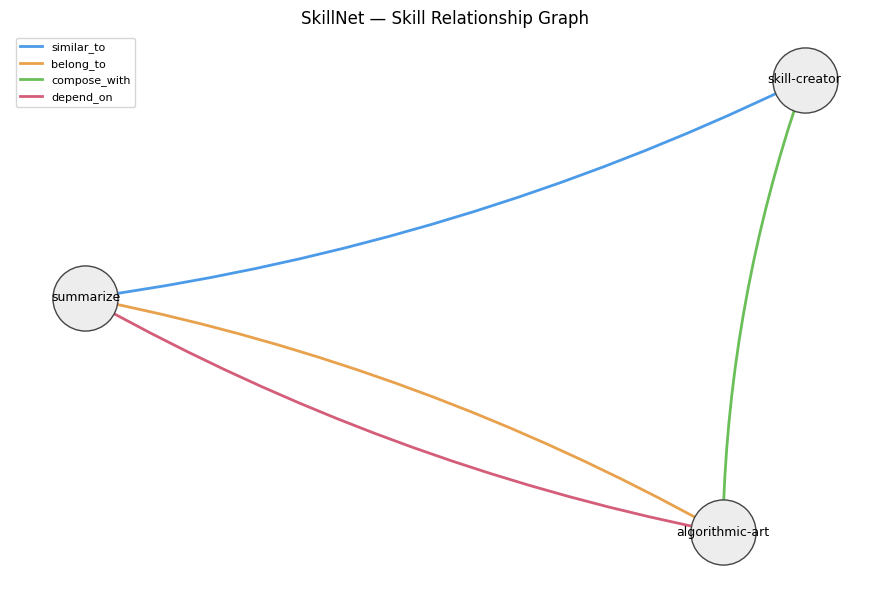

  graph saved -> skillnet_demo/skill_graph.png

  7) Skill-augmented agent planner
GOAL: Analyze scRNA-seq data to find and validate cancer drug targets, then write a report

PLAN (5 steps):

  Step 1: acquire single-cell RNA-seq dataset
     search('acquire single-cell rna-seq dataset') -> bio-single-cell-data-io  ⭐1814

  Step 2: preprocess and cluster cells
     search('preprocess cluster cells') -> seuratsubclustering  ⭐104

  Step 3: identify candidate cancer target genes
     search('identify candidate cancer target') -> Chromosomal_Instability_Agent  ⭐104

  Step 4: validate targets against pathway database
     search('validate targets against pathway') -> target-validation-scorer  ⭐562

  Step 5: generate a discovery report
     search('generate discovery report') -> data-report  ⭐0

Execution order (assembled pipeline):
  bio-single-cell-data-io  ->  seuratsubclustering  ->  Chromosomal_Instability_Agent  ->  target-validation-scorer  ->  data-report

  Tutorial complete

Rec

In [2]:
banner("7) Skill-augmented agent planner")

GOAL = "Analyze scRNA-seq data to find and validate cancer drug targets, then write a report"

def llm_decompose(goal):
    if API_KEY:
        try:
            payload = {
                "model": MODEL,
                "messages": [
                    {"role": "system", "content":
                     "Decompose the user's goal into 3-6 short, ordered subtasks. "
                     "Reply ONLY as a JSON array of strings, no prose, no markdown."},
                    {"role": "user", "content": goal},
                ],
                "temperature": 0.2,
            }
            r = requests.post(f"{BASE_URL}/chat/completions",
                              headers={"Authorization": f"Bearer {API_KEY}"},
                              json=payload, timeout=60)
            r.raise_for_status()
            txt = r.json()["choices"][0]["message"]["content"]
            txt = re.sub(r"^```(?:json)?|```$", "", txt.strip()).strip()
            subs = json.loads(txt)
            if isinstance(subs, list) and subs:
                return [str(x) for x in subs]
        except Exception as e:
            print(f"  LLM decompose failed -> heuristic ({e!r})")
    return ["acquire single-cell RNA-seq dataset",
            "preprocess and cluster cells",
            "identify candidate cancer target genes",
            "validate targets against pathway database",
            "generate a discovery report"]

def keywords_for(subtask):
    stop = {"the", "and", "a", "to", "of", "from", "into", "for", "with", "then", "an"}
    toks = [w for w in re.findall(r"[a-zA-Z\-]+", subtask.lower()) if w not in stop]
    return " ".join(toks[:4])

subtasks = llm_decompose(GOAL)
print(f"GOAL: {GOAL}\n\nPLAN ({len(subtasks)} steps):")

plan = []
for i, st in enumerate(subtasks, 1):
    q = keywords_for(st)
    hits = search(q, mode="vector", limit=2, threshold=0.6) or \
           search(q, mode="keyword", limit=2)
    best = hits[0] if hits else None
    chosen = best["skill_name"] if best else "(no skill found — fallback to base model)"
    plan.append({"step": i, "subtask": st, "query": q, "skill": chosen})
    print(f"\n  Step {i}: {st}")
    print(f"     search('{q}') -> {chosen}" + (f"  ⭐{best['stars']}" if best else ""))

print("\nExecution order (assembled pipeline):")
print("  " + "  ->  ".join(p["skill"].split()[0] if p["skill"][0] != "(" else "base-model"
                            for p in plan))

banner("Tutorial complete")
print(textwrap.dedent(f"""
  Recap:
    • Search (keyword + vector) ............ ran via {'SDK' if USE_SDK else 'REST'}
    • Install (GitHub -> local) ............ {len(installed)} skill(s)
    • Inspect SKILL.md metadata ............ {len(inspected)} parsed
    • Evaluate + quality gate .............. {len(passed)}/{len(targets)} passed {'(LLM)' if API_KEY else '(offline mock)'}
    • Relationship graph ................... {len(rels)} edges -> skill_graph.png
    • Agent planner ........................ {len(plan)} steps mapped to skills
  Docs: https://github.com/zjunlp/SkillNet
"""))